# Re-processing & annotating a published endometrium dataset

**Project aim.** Take a published single-cell dataset, re-process it from raw counts using my own
parameters, then compare my version against the authors'
finished product.

**Dataset.** Non-pregnant human uterus (Non-pregnant Uterus (Endometrium - **Epithelial**), Garcia-Alonso *et al.*, *Nature Genetics* **Mapping the temporal and spatial dynamics of the human endometrium in vivo and in vitro** 2021 —
[doi.org/10.1038/s41588-021-00972-2](https://doi.org/10.1038/s41588-021-00972-2).

Downloaded from CELLxGENE [https://cellxgene.cziscience.com/collections/32f2fd23-ec74-486f-9544-e5b2f41725f5]


**The Structure:**
1. **Setup** 
2. **Getting to know the data** 
3. **Quality control & doublets** 
4. **Reprocessing: logging and normalizing it myself** 
5. **Automated annotation with CellTypist** 
6. **Conclusion** 
7. **Appendix - what batch integration might add** 

## 1. Setup

### 1a. UV kernel Setup 

Full setup instructions are in this folder's [README](README.md).

In short: [install uv](https://docs.astral.sh/uv/getting-started/installation/), run `uv sync` from the project folder, then select `.venv/bin/python` as the kernel.


In [1]:
!uv sync

Resolved 160 packages in 29ms
Checked 157 packages in 45ms


### 1b. Import modules and data

**Aim:** establish the environment in one clear place, so *Restart → Run all* is reproducible.



In [2]:

import celltypist
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
import scanpy as sc
import seaborn as sns
import anndata as ad
import doubletdetection

/Users/fabianbyron/Coding/Github/endo_project/.venv/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [3]:
# doubletdetection's dependency chain sometimes switches matplotlib to non-rendering
%matplotlib inline

In [4]:
# Download (cached) and verify the dataset
URL = "https://datasets.cellxgene.cziscience.com/b1899c6c-b1a6-4340-9df1-b62a00a6e8af.h5ad"
SHA256 = "sha256:ca2860b2656e64dba762e8b19e55469745b626de1b24b1f64c5425f97b372738"

path = pooch.retrieve(
    url=URL,
    known_hash=SHA256,
    fname="endometrium_epithelial.h5ad",
    progressbar=True,
)


In [5]:
# load the dataset
adata = sc.read_h5ad(path)

In [6]:
# show a summary of the dataset
adata

AnnData object with n_obs × n_vars = 10729 × 27506
    obs: 'SampleID', 'log2p1_count', 'percent_mito', 'n_genes', 'donor_id', 'BiopsyType', 'Location', 'Binary Stage', 'Stage', 'Epithelial celltype', 'CellCycle Phase', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'Binary Stage_colors', 'BiopsyType_colors', 'CellCycle Phase_colors', 'Epithelial celltype_colors', 'Location_colors', 'citation', 'default_embedding', 'donor_id_colors', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'sc

In [7]:
# investigate metadata
adata.uns

{'Binary Stage_colors': array(['#008800', '#AA4400'], dtype=object),
 'BiopsyType_colors': array(['#AA0000', '#0000FF'], dtype=object),
 'CellCycle Phase_colors': array(['#6E40AA', '#FF8C38', '#28EA8D'], dtype=object),
 'Epithelial celltype_colors': array(['#974815', '#F08129', '#EAB896', '#F7C900', '#C69E57', '#E53215',
        '#9C1915', '#1B3E92', '#429FD9', '#675DA6'], dtype=object),
 'Location_colors': array(['#0000FF', '#AA0088'], dtype=object),
 'citation': 'Publication: https://doi.org/10.1038/s41588-021-00972-2 Dataset Version: https://datasets.cellxgene.cziscience.com/b1899c6c-b1a6-4340-9df1-b62a00a6e8af.h5ad curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/32f2fd23-ec74-486f-9544-e5b2f41725f5',
 'default_embedding': 'X_umap',
 'donor_id_colors': array(['#a70000', '#e20000', '#4a4a00', '#848400', '#a5a500', '#005917',
        '#009f29', '#00c734', '#004a75', '#0084d2', '#12a7ff', '#410068',
        '#7a00c1', '#bb48f

In [8]:
# Keep the authors' delivered object untouched, and stash the raw integer counts
# in a layer so every step below can reach them. Fix a seed so *Restart -> Run all*
# reproduces the same figures (UMAP etc. use random numbers).
adata_original = adata.copy()
adata.layers["counts"] = adata.raw.X.copy()

sc.settings.verbosity = 1
SEED = 0

## 2. Getting to know the data

**Aim:** exploring the downloaded dataset.

The download is an epithelial subset of the endometrium dataset: **10,729 cells x 27,506 genes**.

In [34]:
import scipy.sparse as sp

R = sp.csr_matrix(adata.raw.X)   # raw UMI counts
X = sp.csr_matrix(adata.X)       # the matrix the authors delivered

print(f"raw.X : integer counts,  max = {R.max()}")
print(f"X               :  max = {round(float(X.max()), 3)}")
print(f"log2(counts + 1):  max = {round(float(np.log2(R.max() + 1)), 3)}")
print("^(the two match, which is what we'd expect if X = log2(counts + 1))")

# The max only tells us the two are *consistent*. The real check that there's no
# per-cell size factor: (2**X - 1)/raw.X should be a flat 1.0 within a cell
# (a size factor would make it bigger for deeply sequenced cells). Spot-check the first cell (row 0):
delog = X[0].toarray().ravel(); delog = 2**delog - 1
ratio = delog / R[0].toarray().ravel()
ratio = ratio[np.isfinite(ratio)]
print(f"per-cell (2**X - 1)/raw.X : mean = {round(ratio.mean(), 4)}  std = {round(ratio.std(), 4)}")

raw.X : integer counts,  max = 9297.0
X               :  max = 13.183
log2(counts + 1):  max = 13.183
^(the two match, which is what we'd expect if X = log2(counts + 1))
per-cell (2**X - 1)/raw.X : mean = 1.0  std = 0.0


**What I saw:** `X` is exactly `log2(counts + 1)` and the per-cell ratio is a flat 1.0,
so there is **no library-size (depth) normalization** baked in. That surprised me; I'd assumed
published data would be depth-normalized. I come back to what that means in section 4.

For orientation, here is the authors' UMAP with their epithelial labels.

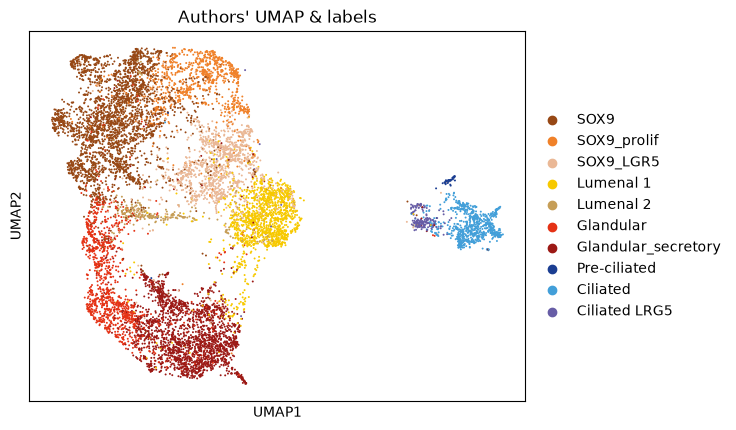

In [35]:
sc.pl.umap(adata, color="Epithelial celltype", size=8, title="Authors' UMAP & labels")

## 3. Quality control & doublets

**Aim:** a quick sanity check that the published data is as clean as expected, and a look for
doublets — I'm not expecting to remove anything, just confirming.

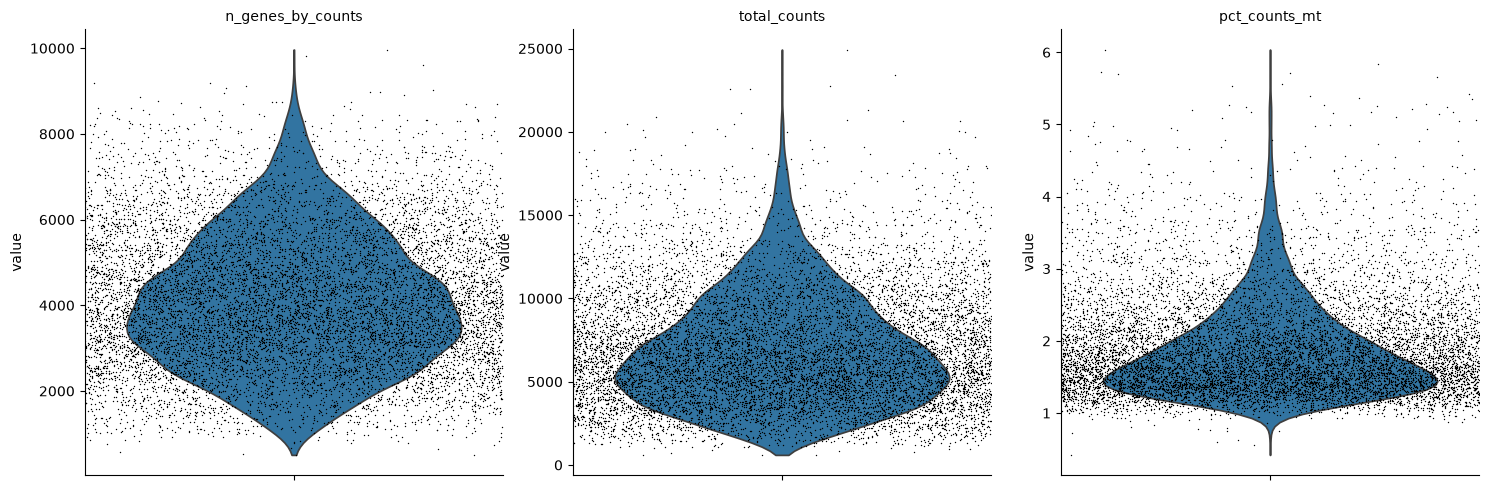

In [36]:
# gene-class flags, then standard QC metrics
adata.var["mt"]   = adata.var["feature_name"].str.startswith("MT")
adata.var["ribo"] = adata.var["feature_name"].str.startswith(("RPS", "RPL"))
adata.var["hb"]   = adata.var["feature_name"].str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True)

sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.5, size=1, multi_panel=True)

  0%|          | 0/10 [00:00<?, ?it/s]

Scrublet flagged        : 0 / 10729
DoubletDetection flagged: 234 / 10729
both agree (doublet)    : 0


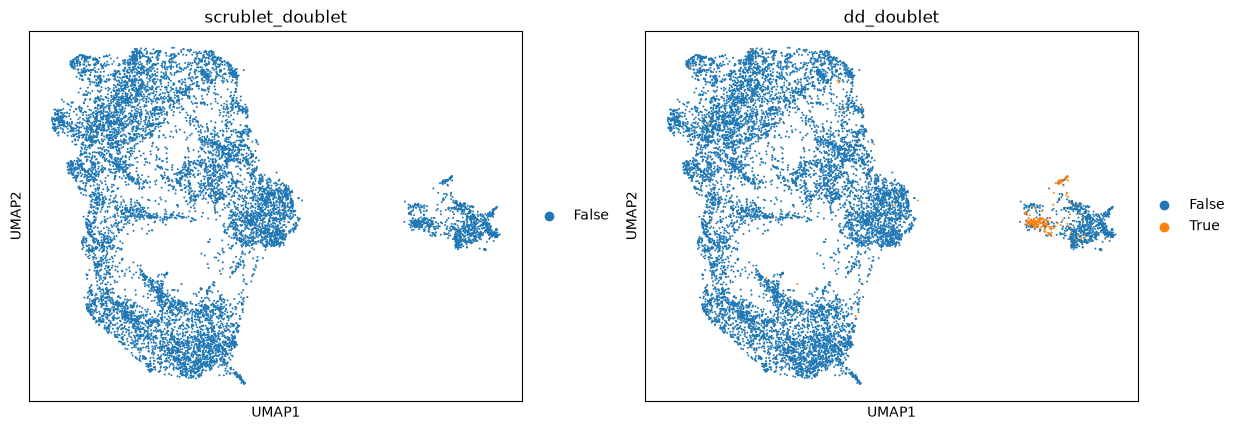

In [37]:


# Both detectors expect RAW COUNTS. Scrublet runs on a counts-only copy so I don't
# disturb adata.X; DoubletDetection reads the counts layer directly (~2 min).
_scr = ad.AnnData(adata.layers["counts"].copy())
sc.pp.scrublet(_scr)
adata.obs["scrublet_doublet"] = _scr.obs["predicted_doublet"].values

clf = doubletdetection.BoostClassifier()
adata.obs["dd_doublet"] = clf.fit(adata.layers["counts"]).predict().astype(bool)

n = adata.n_obs
print(f"Scrublet flagged        : {int(adata.obs['scrublet_doublet'].sum())} / {n}")
print(f"DoubletDetection flagged: {int(adata.obs['dd_doublet'].sum())} / {n}")
print(f"both agree (doublet)    : {int((adata.obs['scrublet_doublet'] & adata.obs['dd_doublet']).sum())}")

sc.pl.umap(adata, color=["scrublet_doublet", "dd_doublet"], size=8)

Scrublet flagged        : 0 / 10729
DoubletDetection flagged: 234 / 10729
both agree (doublet)    : 0


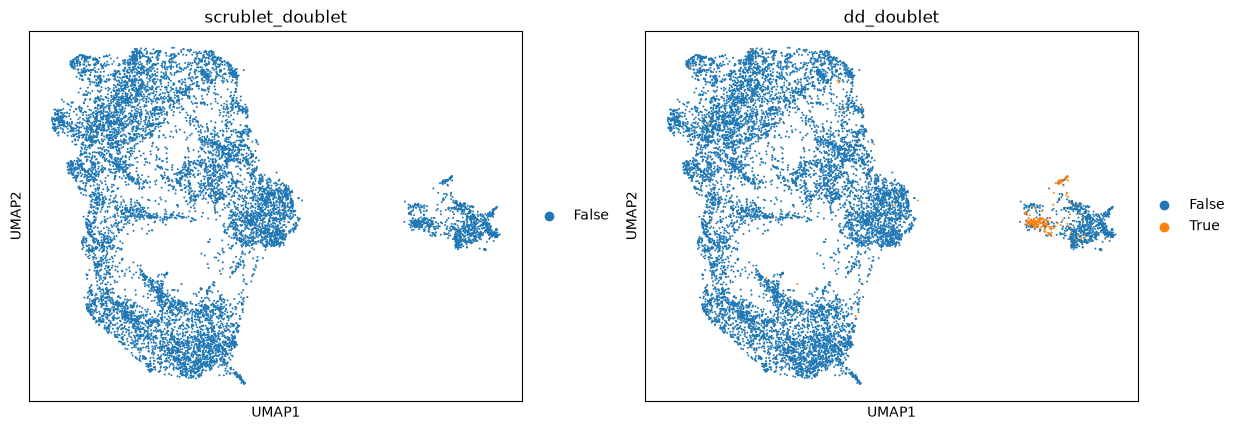

In [38]:
n = adata.n_obs
print(f"Scrublet flagged        : {int(adata.obs['scrublet_doublet'].sum())} / {n}")
print(f"DoubletDetection flagged: {int(adata.obs['dd_doublet'].sum())} / {n}")
print(f"both agree (doublet)    : {int((adata.obs['scrublet_doublet'] & adata.obs['dd_doublet']).sum())}")

sc.pl.umap(adata, color=["scrublet_doublet", "dd_doublet"], size=8)

**What I saw:** Scrublet flags essentially nothing, DoubletDetection flags ~2% of cells. Detecting no doublets on an unprocessed dataset would be very unusual but this data has already been process before I downloaded it.

I think DoubletDetection is giving false positives. This section highlights that identifying doublets can be difficult and that with false positives there is a risk of accidentally removing valid cell types.

## 4. Reprocessing: normalizing it myself

**Aim:** since the delivered matrix isn't depth-normalized (section 2), I wanted to try
normalizing it in a standard way (CP10K + `log1p`) and see what changes downstream.
This is one thing I explored, not a claim that the authors did anything wrong.

In [39]:
# Two matrices to compare, both from the same raw counts:
adata.layers["original"] = adata_original.X.copy()          # authors: log2(counts + 1)

norm = ad.AnnData(adata.layers["counts"].copy())
sc.pp.normalize_total(norm, target_sum=1e4)                 # my reprocessing: CP10K ...
sc.pp.log1p(norm)                                           # ... + log1p
adata.layers["lognorm"] = norm.X.copy()

# One shared recipe so the comparison is apples-to-apples.
def embed(matrix):
    a = ad.AnnData(X=matrix.copy(), obs=adata.obs.copy(), var=adata.var.copy())
    sc.pp.highly_variable_genes(a, n_top_genes=2000)
    sc.pp.pca(a, n_comps=50, random_state=SEED)
    sc.pp.neighbors(a, random_state=SEED)
    sc.tl.umap(a, random_state=SEED)
    return a

emb = {"original": embed(adata.layers["original"]),
       "lognorm":  embed(adata.layers["lognorm"])}

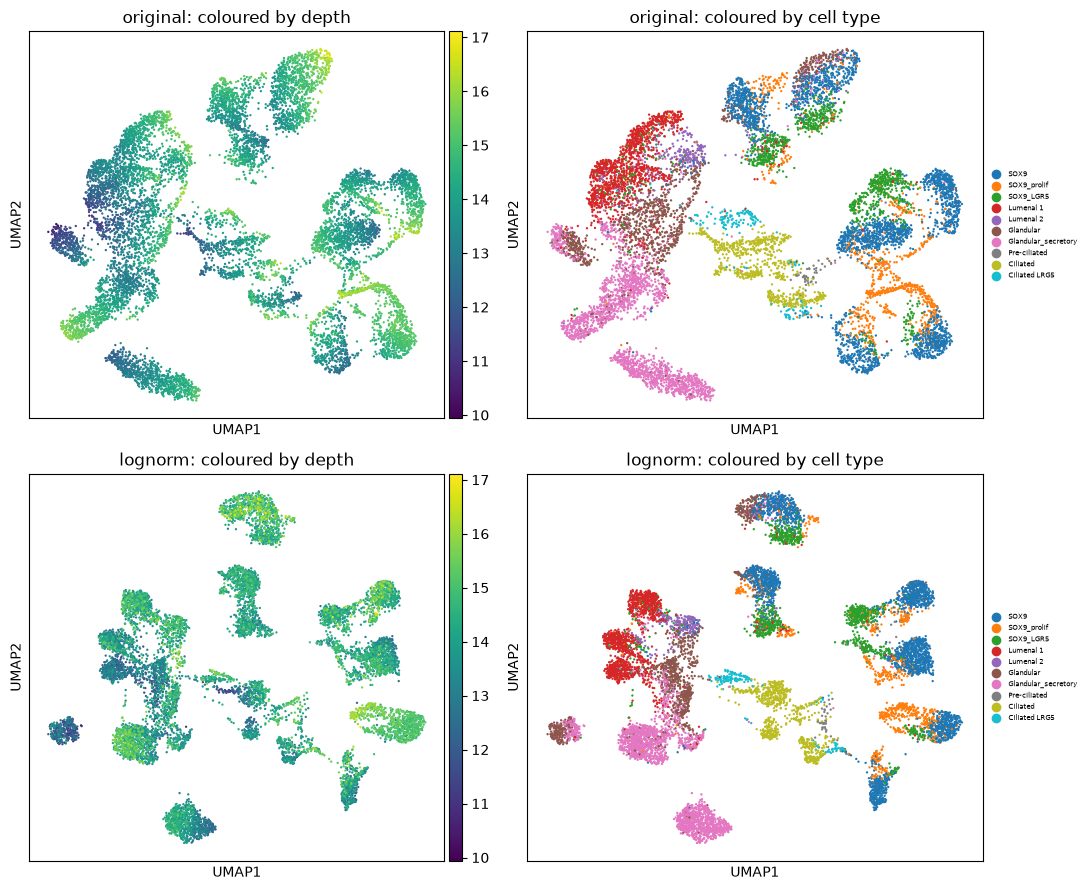

In [40]:
# UMAP orientation is arbitrary (a flip is just a mirror — distances are unchanged), so
# reflect each panel to put Glandular_secretory bottom-left, making the two rows comparable.
def orient_bottom_left(a, key="Epithelial celltype", label="Glandular_secretory"):
    U = a.obsm["X_umap"]
    mask = (a.obs[key].astype(str) == label).values
    center, ref = U.mean(0), U[mask].mean(0)
    if ref[0] > center[0]: U[:, 0] = 2 * center[0] - U[:, 0]   # reflect X about centre
    if ref[1] > center[1]: U[:, 1] = 2 * center[1] - U[:, 1]   # reflect Y about centre

for m in ["original", "lognorm"]:
    orient_bottom_left(emb[m])

# rows = matrix, cols = coloured by sequencing depth / by cell type
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, m in enumerate(["original", "lognorm"]):
    sc.pl.umap(emb[m], color="log2p1_count", ax=axes[i, 0], show=False,
               title=f"{m}: coloured by depth")
    sc.pl.umap(emb[m], color="Epithelial celltype", ax=axes[i, 1], show=False,
               title=f"{m}: coloured by cell type", legend_fontsize=5)
plt.tight_layout(); plt.show()

In [41]:
from sklearn.metrics import silhouette_score


# For each matrix: how much does (continuous) sequencing depth leak into the top PCs, and how
# well do the cell types separate? Depth is continuous so it's measured by correlation with the
# PCs; silhouette scores cell-type separation. (Categorical covariates like donor/Stage use NMI
# in the next cell.)
def pc_depth_corr(a, k=15):
    pcs = a.obsm["X_pca"][:, :k]
    d = a.obs["total_counts"].values
    return max(abs(np.corrcoef(pcs[:, i], d)[0, 1]) for i in range(k))

pd.DataFrame([
    {"matrix": m,
     "max|PC-depth r| (top15)": round(pc_depth_corr(emb[m]), 3),
     "silhouette (cell type)": round(
         silhouette_score(emb[m].obsm["X_pca"], emb[m].obs["Epithelial celltype"]), 3)}
    for m in ["original", "lognorm"]
])

,matrix,max|PC-depth r| (top15),silhouette (cell type)
0,original,0.660,0.098
1,lognorm,0.364,0.108


**What I saw:** the "top PCs" are the main axes of variation that everything downstream (clustering, UMAP) is built on. Before normalizing, sequencing depth leaks strongly into them (correlation ~0.66); afterwards it's about half that (~0.36) — so depth is no longer a main driver. But the cell types separate about equally well either way: the silhouette score (higher = more distinct groups) barely moves, ~0.10 → ~0.11. So depth was shaping the embedding, yet removing it changed the separation of cell types very little.

In [42]:
# Does normalization change what structures the embedding? Cluster each embedding's PCA
# into "islands" and see how strongly each covariate aligns with them (NMI).
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score as nmi

candidates = ["donor_id", "SampleID", "Stage", "Epithelial celltype", "Binary Stage",
              "Location", "BiopsyType", "CellCycle Phase", "depth_bin"]

def island_nmi(a):
    islands = KMeans(n_clusters=15, n_init=5, random_state=SEED).fit_predict(a.obsm["X_pca"])
    a.obs["depth_bin"] = pd.qcut(a.obs["total_counts"], 6, labels=False, duplicates="drop").astype(str)
    return {c: round(nmi(islands, a.obs[c].astype(str)), 3) for c in candidates}

tab = pd.DataFrame({"original": island_nmi(emb["original"]),
                    "lognorm":  island_nmi(emb["lognorm"])})
tab["change"] = (tab["lognorm"] - tab["original"]).round(3)
tab.sort_values("lognorm", ascending=False)

,original,lognorm,change
donor_id,0.560,0.699,0.139
SampleID,0.554,0.691,0.137
Stage,0.490,0.591,0.101
Epithelial celltype,0.498,0.543,0.045
Binary Stage,0.329,0.359,0.030
Location,0.069,0.135,0.066
BiopsyType,0.069,0.135,0.066
CellCycle Phase,0.075,0.082,0.007
depth_bin,0.256,0.075,-0.181


**What I saw:** once depth is normalized out, the structure that remains lines up most with donor / sample and hardly at all with sequencing depth. The natural next step might be looking into batch integration (Harmony, scVI) although this would need to be done while still respecting the real and expected effect of Stage.

## 5. Automated annotation with CellTypist

**Aim:** get an automated reproducible annotation on cell identity and compare it to the authors' labels — run on my reprocessed embedding (CP10K + log1p is exactly what CellTypist expects). I use the endometrium atlas (same tissue) plus an intestinal model as an out-of-tissue comparison.

In [43]:
from celltypist import models
models.download_models(force_update=False)

ct = emb["lognorm"].copy()                       # my re-embedded, CP10K+log1p data
ct.var_names = ct.var["feature_name"].astype(str)
ct.var_names_make_unique()
print(f"per-cell expm1 sum (want ~1e4): {np.round(np.expm1(ct.X[:3].toarray()).sum(1))}")

📂 Storing models in /Users/fabianbyron/.celltypist/data/models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/61]: Autopsy_COVID19_Lung.

per-cell expm1 sum (want ~1e4): [10000. 10000. 10000.]


In [44]:
ct.obs["atlas"] = celltypist.annotate(
    ct, model="Human_Endometrium_Atlas.pkl", majority_voting=True).to_adata().obs["majority_voting"].values
ct.obs["intestinal"] = celltypist.annotate(
    ct, model="Cells_Intestinal_Tract.pkl", majority_voting=True).to_adata().obs["majority_voting"].values

🔬 Input data has 10729 cells and 27506 genes
🔗 Matching reference genes in the model
🧬 3633 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 10729 cells and 27506 genes
🔗 Matching reference genes in the model
🧬 4243 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


... storing 'depth_bin' as categorical


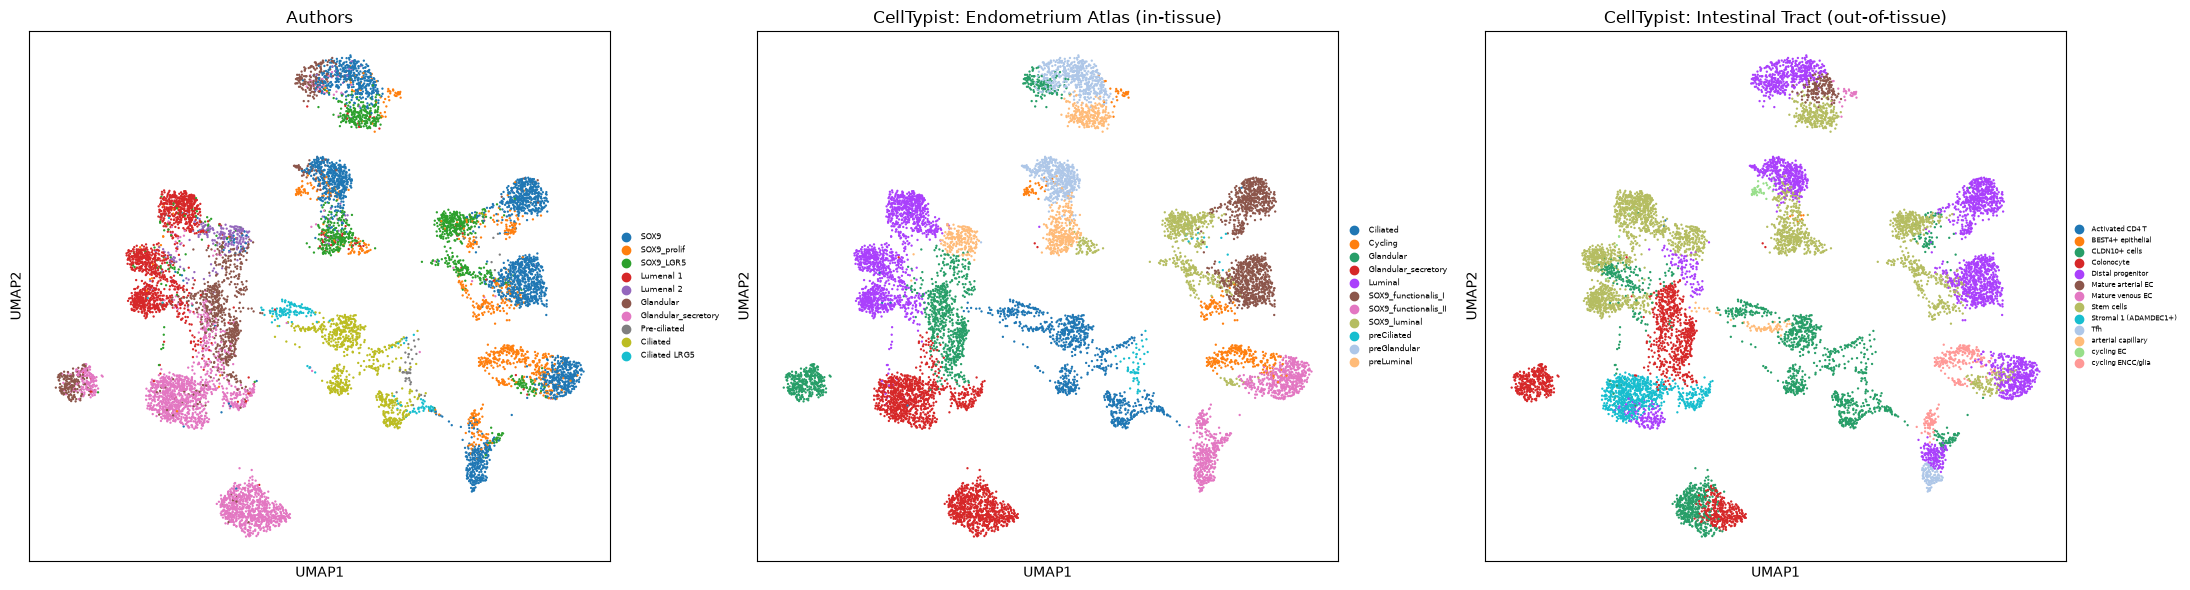

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sc.pl.umap(ct, color="Epithelial celltype", ax=axes[0], show=False, title="Authors", legend_fontsize=6)
sc.pl.umap(ct, color="atlas", ax=axes[1], show=False, title="CellTypist: Endometrium Atlas (in-tissue)", legend_fontsize=6)
sc.pl.umap(ct, color="intestinal", ax=axes[2], show=False, title="CellTypist: Intestinal Tract (out-of-tissue)", legend_fontsize=5)
plt.tight_layout(); plt.show()

,model,ARI,NMI
0,Endometrium Atlas (in-tissue),0.522,0.621
1,Intestinal Tract (out-of-tissue),0.377,0.483


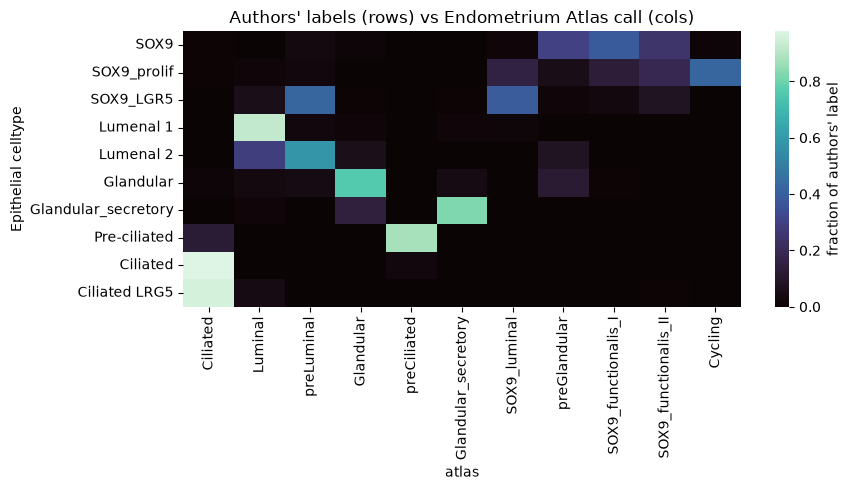

In [46]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

author = ct.obs["Epithelial celltype"]
agree = pd.DataFrame([
    {"model": "Endometrium Atlas (in-tissue)",
     "ARI": round(adjusted_rand_score(author, ct.obs["atlas"]), 3),
     "NMI": round(normalized_mutual_info_score(author, ct.obs["atlas"]), 3)},
    {"model": "Intestinal Tract (out-of-tissue)",
     "ARI": round(adjusted_rand_score(author, ct.obs["intestinal"]), 3),
     "NMI": round(normalized_mutual_info_score(author, ct.obs["intestinal"]), 3)},
])
display(agree)

# where does each authors' label land in the atlas call?
cx = pd.crosstab(author, ct.obs["atlas"], normalize="index")
cx = cx.loc[:, cx.sum().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(cx, cmap="mako", ax=ax, cbar_kws={"label": "fraction of authors' label"})
ax.set_title("Authors' labels (rows) vs Endometrium Atlas call (cols)")
plt.tight_layout(); plt.show()

**What I saw:** the in-tissue atlas agrees with the authors far more than the out-of-tissue
intestinal model (higher ARI/NMI), which is expected. A few caveats:
the endometrium atlas comes from the same study lineage, so agreement is reassuring but **not
independent**

## 6. Conclusion

- **The data was already clean.** The two doublet methods disagreed, so I kept every
  cell rather than trust one of them.
- **The delivered matrix wasn't depth-normalized**, which surprised me. Normalizing it myself
  cut depth's leakage into the top PCs roughly in half, but barely changed how well the cell
  types separate.
- **CellTypist broadly agrees with the authors**, more so for the in-tissue model than the
  out-of-tissue control — a nice independent-ish check on the published labels.
- **The structure that remains is mostly donor/batch**, so batch integration (e.g. Harmony,
  scVI) would be a possible next step, but it would need to respect real biology like cycle Stage.

This week I learned some of the why behind each scanpy step by working through them
one at a time in a separate exploration notebook, alongside the [single-cell best practices guide](https://www.sc-best-practices.org).

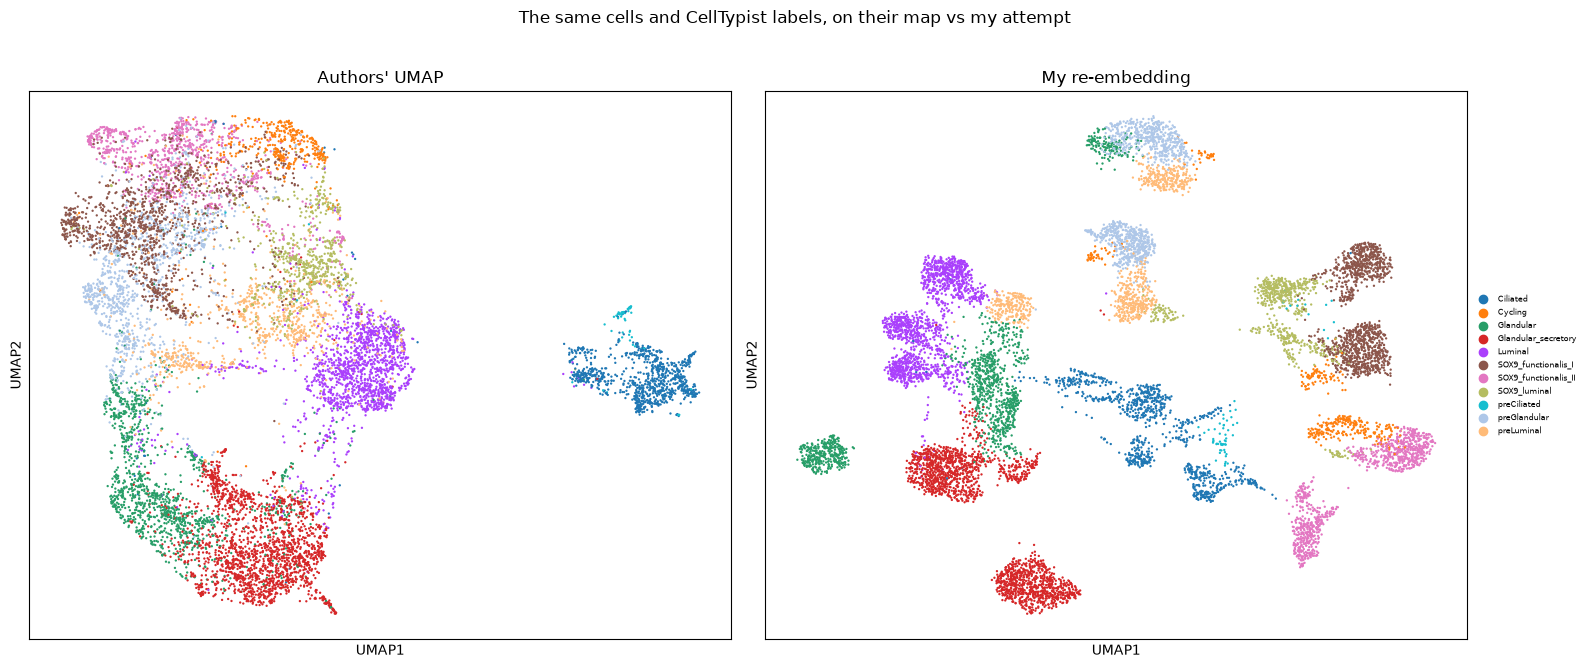

In [ ]:
from pathlib import Path

# Casual finish: same cells, same CellTypist labels, on the authors' UMAP vs my re-embedding.
# One label set on both => the colours match cell-for-cell (no harmonising needed).
labels = ct.obs["atlas"].astype(str)
cats = sorted(labels.unique())
pal = list(sc.pl.palettes.default_20)[:len(cats)]

orig = adata_original.copy()
orig.obs["atlas"] = pd.Categorical(labels.reindex(orig.obs_names), categories=cats)
mine = ct.copy()
mine.obs["atlas"] = pd.Categorical(labels, categories=cats)
orig.uns["atlas_colors"] = mine.uns["atlas_colors"] = pal   # identical palette on both

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
sc.pl.umap(orig, color="atlas", ax=axes[0], show=False,
           title="Authors' UMAP", legend_loc="none")
sc.pl.umap(mine, color="atlas", ax=axes[1], show=False,
           title="My re-embedding", legend_fontsize=6)
fig.suptitle("The same cells and CellTypist labels, on their map vs my attempt", y=1.02)
plt.tight_layout()

#Path("figures").mkdir(exist_ok=True)
#fig.savefig("figures/start_vs_finish.png", dpi=150, bbox_inches="tight")
#plt.show()

![Their UMAP vs mine, same CellTypist labels](figures/start_vs_finish.png)

**Where I ended up:** the same cells and CellTypist labels on the authors' original UMAP (left) and my own re-processed one (right). Not identical, but the same groups land in the same neighborhoods. Mine shows a less continuous and more clumpy map - this is potentially misleading as the clumping is largely due to batch effects.An ideal map would probably show more of a continuum: this is a tissue with lots of active differentiation, so more gradual transitions between cell types might be what you'd expect.

## 7. Appendix - what batch integration might add
Batch integration was out of scope for the main notebook, but here's a quick look. Same reprocessing and CellTypist labels; the only change is running Harmony on donor_id before building the graph. Without it (left) the map fragments into donor-driven islands — the same cell type appears in several. With it (right) those collapse into the differentiation continuum you'd expect, and the donor structure drops sharply (NMI(islands, donor) 0.70 → 0.35). Ciliated stays separate either way.

![a breif preview of batch integration](figures/harmony_comparison_.png)